# **Decision Tree Regressor**

---

<br>

## What is a Decision Tree?
Answer: **Decision Tree** is a tree-like model used for decision-making and predictive modeling. It splits data into smaller subsets based on feature conditions, creating a tree structure of decision rules.

In regression:
- It predicts continuous target values by learning rules from the data.
- The prediction is the mean value of the target variable in the leaf node.

<br>

---

<br>

### Important Points:

1. **Tree Structure**:
   - The model splits the data based on features to form a tree.
   - Each **node** represents a decision (a feature), and each **leaf node** represents a predicted value (continuous target).

2. **Splitting Criteria**:
   - It uses **variance reduction** or **mean absolute error** to decide the best feature for splitting at each node.
   - The aim is to minimize the variance or absolute error in the target variable within the groups at each leaf node.

3. **Recursion**:
   - The tree keeps splitting data recursively until it reaches stopping criteria like **max depth** or **minimum samples per leaf**.

4. **Overfitting**:
   - Decision Trees can overfit if they grow too deep, leading to poor generalization on unseen data. Controlling depth is crucial.

5. **Post-pruning**:
   - **Prunes back** the tree after it’s fully grown by removing branches that provide little predictive value, to improve generalization.

6. **Pre-pruning**:
   - **Stops the tree from growing too deep** by setting limits like maximum depth or minimum samples per leaf, to prevent overfitting.

7. **Interpretability**:
   - Decision Trees are easy to understand and visualize, making them a **transparent** model.

8. **Making Predictions**:
   - Predictions are made by **traversing** the tree from the root to the appropriate leaf node based on feature values. The predicted value is the **mean** (or another aggregation) of the target values in that leaf.

<br>

---

<br>

### Key Parameters to Tune:

1. **`max_depth`**:
   - Limits the maximum depth of the tree.
   - Prevents overfitting by restricting how complex the tree can grow.
   - Example: `max_depth=3`

2. **`min_samples_split`**:
   - The minimum number of samples required to split an internal node.
   - Higher values prevent splits on small datasets.
   - Example: `min_samples_split=5`

3. **`min_samples_leaf`**:
   - The minimum number of samples required at a leaf node.
   - Controls the size of terminal nodes.
   - Example: `min_samples_leaf=2`

4. **`criterion`**:
   - Determines the function to measure the quality of a split.
   - Common options:
     - `squared_error` (default for regression): Minimizes the variance of the target variable.
     - `absolute_error`: Minimizes the absolute difference between predicted and actual values.

5. **`random_state`**:
   - Ensures reproducibility by fixing the random seed.
   - Example: `random_state=42`

<br>

---

<br>

### Advantages:
- Easy to interpret and visualize.
- Handles both numerical and categorical data.
- Non-parametric: No assumptions about data distribution.

### Disadvantages:
- Prone to overfitting on small datasets.
- Sensitive to small changes in the data.
- May require pruning or parameter tuning for optimal performance.

<br>

---


<br>

## Overview:
Decision Tree Regressor splits data into decision nodes, learns to partition based on important features, and predicts continuous target values by following the tree’s structure. It’s a powerful, interpretable model, but can overfit if not controlled.

<br>

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/content/41_laptop_prices.csv')

In [3]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [4]:
df

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,4,Windows 10,1.80,638.00,Full HD,1920,...,No,Intel,2.5,Core i7 6500U,128,0,SSD,No,Intel,HD Graphics 520
1271,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,16,Windows 10,1.30,1499.00,Quad HD+,3200,...,No,Intel,2.5,Core i7 6500U,512,0,SSD,No,Intel,HD Graphics 520
1272,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,2,Windows 10,1.50,229.00,Standard,1366,...,No,Intel,1.6,Celeron Dual Core N3050,64,0,Flash Storage,No,Intel,HD Graphics
1273,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,6,Windows 10,2.19,764.00,Standard,1366,...,No,Intel,2.5,Core i7 6500U,1024,0,HDD,No,AMD,Radeon R5 M330


In [5]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [6]:
df.shape

(1275, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [8]:
df.isnull().sum()

,0
Company,0
Product,0
TypeName,0
Inches,0
Ram,0
OS,0
Weight,0
Price_euros,0
Screen,0
ScreenW,0


In [9]:
df.duplicated().sum()

0

In [10]:
df.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [11]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [12]:
le = LabelEncoder()
df['Company'] = le.fit_transform(df['Company'])
df['Product'] = le.fit_transform(df['Product'])
df['TypeName'] = le.fit_transform(df['TypeName'])
df['OS'] = le.fit_transform(df['OS'])
df['Screen'] = le.fit_transform(df['Screen'])
df['Touchscreen'] = le.fit_transform(df['Touchscreen'])
df['IPSpanel'] = le.fit_transform(df['IPSpanel'])
df['RetinaDisplay'] = le.fit_transform(df['RetinaDisplay'])
df['CPU_company'] = le.fit_transform(df['CPU_company'])
df['CPU_model'] = le.fit_transform(df['CPU_model'])
df['PrimaryStorage'] = le.fit_transform(df['PrimaryStorage'])
df['SecondaryStorageType'] = le.fit_transform(df['SecondaryStorageType'])
df['PrimaryStorageType'] = le.fit_transform(df['PrimaryStorageType'])
df['GPU_company'] = le.fit_transform(df['GPU_company'])
df['GPU_model'] = le.fit_transform(df['GPU_model'])


In [13]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,1,300,4,13.3,8,8,1.37,1339.69,3,2560,...,1,1,2.3,40,4,0,3,2,2,60
1,1,301,4,13.3,8,8,1.34,898.94,3,1440,...,0,1,1.8,40,4,0,0,2,2,53
2,7,50,3,15.6,8,4,1.86,575.00,1,1920,...,0,1,2.5,46,7,0,3,2,2,55
3,1,300,4,15.4,16,8,1.83,2537.45,3,2880,...,1,1,2.7,54,10,0,3,2,0,80
4,1,300,4,13.3,8,8,1.37,1803.60,3,2560,...,1,1,3.1,40,7,0,3,2,2,61


In [14]:
df.describe()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,...,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,6.460392,307.334902,2.582745,15.022902,8.440784,4.814118,2.040525,1134.969059,1.567059,1900.043922,...,0.013333,0.953725,2.302980,50.250980,7.545882,176.069020,2.263529,1.684706,2.036863,50.439216
std,4.096247,171.162972,1.247925,1.429470,5.097809,1.034319,0.669196,700.752504,0.944710,493.346186,...,0.114743,0.213864,0.503846,16.982392,2.587870,415.960655,1.045080,0.734469,0.925510,26.471365
min,0.000000,0.000000,0.000000,10.100000,2.000000,0.000000,0.690000,174.000000,0.000000,1366.000000,...,0.000000,0.000000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,180.500000,1.000000,14.000000,4.000000,5.000000,1.500000,609.000000,1.000000,1920.000000,...,0.000000,1.000000,2.000000,41.000000,7.000000,0.000000,1.000000,2.000000,2.000000,31.000000
50%,7.000000,291.000000,3.000000,15.600000,8.000000,5.000000,2.040000,989.000000,1.000000,1920.000000,...,0.000000,1.000000,2.500000,52.000000,7.000000,0.000000,3.000000,2.000000,2.000000,49.000000
75%,10.000000,454.500000,3.000000,15.600000,8.000000,5.000000,2.310000,1496.500000,3.000000,1920.000000,...,0.000000,1.000000,2.700000,62.000000,10.000000,0.000000,3.000000,2.000000,3.000000,55.000000
max,18.000000,617.000000,5.000000,18.400000,64.000000,8.000000,4.700000,6099.000000,3.000000,3840.000000,...,1.000000,2.000000,3.600000,92.000000,12.000000,2048.000000,3.000000,3.000000,3.000000,109.000000


In [15]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [16]:
#X = df.drop(["Price_euros","TypeName", "Product", "ScreenW", "ScreenH", "CPU_freq"], axis = 1)
X = df.drop(["Price_euros"], axis = 1)
Y = df['Price_euros']

In [17]:
X_train,X_test,Y_train, Y_test = train_test_split(X,Y, test_size = 0.2)

In [18]:
'''scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)'''

'scaler = StandardScaler()\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.transform(X_test)'

In [19]:
model = DecisionTreeRegressor(random_state = 0)
model.fit(X_train, Y_train)

DecisionTreeRegressor(random_state=0)

[Text(0.6672519500186715, 0.9827586206896551, 'x[4] <= 14.0\nsquared_error = 500936.609\nsamples = 1020\nvalue = 1154.206'),
 Text(0.3588439479654724, 0.9482758620689655, 'x[4] <= 7.0\nsquared_error = 262184.635\nsamples = 830\nvalue = 948.6'),
 Text(0.513047948992072, 0.9655172413793103, 'True  '),
 Text(0.1609031121045392, 0.9137931034482759, 'x[14] <= 2.25\nsquared_error = 71178.169\nsamples = 323\nvalue = 562.298'),
 Text(0.08563445667125172, 0.8793103448275862, 'x[15] <= 23.5\nsquared_error = 24590.103\nsamples = 169\nvalue = 419.183'),
 Text(0.05569119669876203, 0.8448275862068966, 'x[10] <= 0.5\nsquared_error = 7895.241\nsamples = 69\nvalue = 311.939'),
 Text(0.04095598349381018, 0.8103448275862069, 'x[21] <= 46.0\nsquared_error = 4236.606\nsamples = 58\nvalue = 291.785'),
 Text(0.0202888583218707, 0.7758620689655172, 'x[15] <= 19.0\nsquared_error = 3021.169\nsamples = 52\nvalue = 280.858'),
 Text(0.005502063273727648, 0.7413793103448276, 'x[9] <= 924.0\nsquared_error = 2296.262

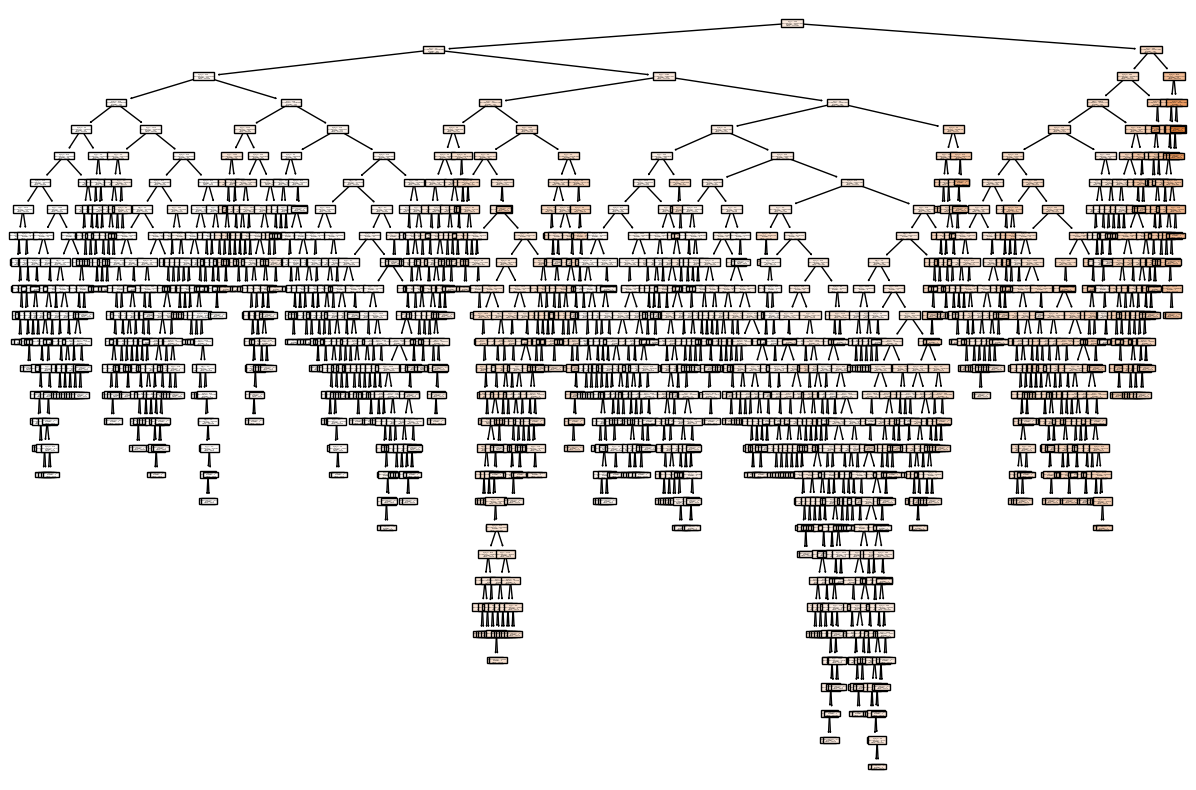

In [20]:
from sklearn import tree
plt.figure(figsize = (15,10))
tree.plot_tree(model,filled = True)

In [21]:
Y_pred = model.predict(X_test)

In [22]:
X_pred_train = model.predict(X_train)
r2_score(Y_train, X_pred_train)

0.9997416082020331

In [23]:
mse = mean_squared_error(Y_test, Y_pred)
print(mse)

99672.63693098038


In [24]:
mae = mean_absolute_error(Y_test, Y_pred)
print(mae)

196.33019607843136


In [25]:
r2 = r2_score(Y_test, Y_pred)
print(r2)

0.7745966405556775
